<a href="https://colab.research.google.com/github/vsmacedo-datafinance/Challenge_Locaweb_FIAP_2026/blob/main/notebooks/05_Catboost_Risco_de_Viola%C3%A7%C3%A3o_de_OLA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Projeto Chronos**
##CHALLENGE LOCAWEB 2026
Integrantes:

* Bruno Rosa - RM563779
* Danilo Alves - RM564109
* Enzo Cremaschi - RM562058
* Vinícius Macedo - RM561911

# 05 — Desafio 3: Risco de Violação de OLA/KPI (CatBoost) | Projeto Chronos

**Objetivo:** prever, no instante de abertura de um chamado, a probabilidade de violação do SLA/OLA (`KPI Violado?`), usando tudo que já validamos no projeto até aqui.

**Premissas utilizadas:**
- Vazamento: `gold_chamados_risco` já exclui `Resolvido`, `Encerrado`, `Duração`, `Código de fechamento`, `Solução` e `Status` — colunas que só existem depois do fechamento do chamado.
- Desbalanceamento: 0,95% de positivos (238 em 25.156 chamados elegíveis) — usar `auto_class_weights='Balanced'`.
- Encoding de categóricas: o Ordered Target Statistics do CatBoost calcula isso dentro do próprio ajuste, usando só o treino de cada fold.
- Validação: walk-forward em janela expansiva, os mesmos 3 folds (mesmos limites de semana) usados no Desafio 1, agora aplicados por timestamp de chamado (`aplicar_fold_por_timestamp`).
- Métricas: PR-AUC como referência primária, Precision@K, intervalo de confiança por bootstrap.
> **Revisão de 06/09 (briefing de continuidade).** Células marcadas com `# [REV 06/09]` foram alteradas ou criadas nesta revisão e estão sem output: **reexecutar do zero, com kernel reiniciado**, e comparar os números finais com os já documentados no README antes de commitar.


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/cronos_project')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    setup_logging, PROJECT_PATHS, load_parquet_layer, generate_expanding_folds,
    flag_low_volume_groups, aplicar_fold_por_timestamp, treinar_catboost_fold,
    treinar_catboost_producao, otimizar_hiperparametros_catboost, avaliar_classificador_raro,
    calibrar_threshold_por_custo, bootstrap_metric_ci, precision_at_k, preparar_categoricas_catboost, salvar_modelo_catboost,
    checar_faixa_kpi, FAIXAS_VOLUME_ANUAL_P2, FAIXAS_VOLUME_ANUAL_P3,
    calibrar_threshold_fold, avaliar_threshold,  # [REV 06/09] Pendência 2
    FAIXAS_OLA_QUEBRADO_ANUAL_P2, FAIXAS_OLA_QUEBRADO_ANUAL_P3,
)

logger = setup_logging('catboost_risco')

In [ ]:
!pip install catboost optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 18.8 MB/s eta 0:00:00


## 1. Carga da Gold

In [ ]:
gold_risco_path = PROJECT_PATHS.gold / 'gold_chamados_risco.parquet'
df = load_parquet_layer(gold_risco_path, logger=logger)
df['Aberto'] = pd.to_datetime(df['Aberto'])
logger.info('Carregado: %d chamados x %d colunas.', *df.shape)

logger.info('Distribuição de Prioridade na base completa:\n%s', df['Prioridade'].value_counts(dropna=False).to_string())
if '1 - Crítica' not in df['Prioridade'].unique():
    logger.warning("'1 - Crítica' não aparece na base — as metas oficiais de KPI (dicionário v2) também não têm faixa definida para essa prioridade, então isso é consistente, não um alerta de dado faltando.")


2026-09-10 21:46:06 | INFO     | catboost_risco | Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 35 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


INFO:catboost_risco:Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 35 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


2026-09-10 21:46:06 | INFO     | catboost_risco | Carregado: 121811 chamados x 37 colunas.


INFO:catboost_risco:Carregado: 121811 chamados x 37 colunas.


2026-09-10 21:46:06 | INFO     | catboost_risco | Distribuição de Prioridade na base completa:
Prioridade
4 - Baixa          64580
3 - Média          41260
2 - Alta           15645
5 - Muito Baixa      325
1 - Crítica            1


INFO:catboost_risco:Distribuição de Prioridade na base completa:
Prioridade
4 - Baixa          64580
3 - Média          41260
2 - Alta           15645
5 - Muito Baixa      325
1 - Crítica            1


## 2. Filtro de elegibilidade + ajuste em `grupo_baixo_volume`

O alvo `KPI Violado?` só é definido para chamados com `Entrou para KPI? == 'SIM'` — o universo elegível é uma fatia da base total.

In [ ]:
df_elegivel = df[df['Entrou para KPI?'] == 'SIM'].copy()
df_elegivel['target'] = (df_elegivel['KPI Violado?'] == 'SIM').astype(int)

logger.info(
    'Universo elegível: %d chamados (%.1f%% da base total) | Positivos: %d (%.2f%%)',
    len(df_elegivel), len(df_elegivel) / len(df) * 100,
    df_elegivel['target'].sum(), df_elegivel['target'].mean() * 100,
)

2026-09-10 21:46:06 | INFO     | catboost_risco | Universo elegível: 25156 chamados (20.7% da base total) | Positivos: 238 (0.95%)


INFO:catboost_risco:Universo elegível: 25156 chamados (20.7% da base total) | Positivos: 238 (0.95%)


### 2.1 Validação cruzada com as metas oficiais de KPI

In [ ]:

volume_p2 = int((df_elegivel['Prioridade'] == '2 - Alta').sum())
volume_p3 = int((df_elegivel['Prioridade'] == '3 - Média').sum())
ola_quebrado_p2 = int(((df_elegivel['Prioridade'] == '2 - Alta') & (df_elegivel['target'] == 1)).sum())
ola_quebrado_p3 = int(((df_elegivel['Prioridade'] == '3 - Média') & (df_elegivel['target'] == 1)).sum())

logger.info('Volume elegível P2 = %d -> %s%% de atingimento', volume_p2, checar_faixa_kpi(volume_p2, FAIXAS_VOLUME_ANUAL_P2))
logger.info('Volume elegível P3 = %d -> %s%% de atingimento', volume_p3, checar_faixa_kpi(volume_p3, FAIXAS_VOLUME_ANUAL_P3))
logger.info('OLA quebrado P2 = %d -> %s%% de atingimento', ola_quebrado_p2, checar_faixa_kpi(ola_quebrado_p2, FAIXAS_OLA_QUEBRADO_ANUAL_P2))
logger.info('OLA quebrado P3 = %d -> %s%% de atingimento', ola_quebrado_p3, checar_faixa_kpi(ola_quebrado_p3, FAIXAS_OLA_QUEBRADO_ANUAL_P3))

assert all(checar_faixa_kpi(v, f) is not None for v, f in [
    (volume_p2, FAIXAS_VOLUME_ANUAL_P2), (volume_p3, FAIXAS_VOLUME_ANUAL_P3),
    (ola_quebrado_p2, FAIXAS_OLA_QUEBRADO_ANUAL_P2), (ola_quebrado_p3, FAIXAS_OLA_QUEBRADO_ANUAL_P3),
]), 'Algum número caiu fora de todas as faixas oficiais — checar filtro de elegibilidade!'


2026-09-10 21:46:06 | INFO     | catboost_risco | Volume elegível P2 = 5159 -> 125% de atingimento


INFO:catboost_risco:Volume elegível P2 = 5159 -> 125% de atingimento


2026-09-10 21:46:06 | INFO     | catboost_risco | Volume elegível P3 = 19997 -> 125% de atingimento


INFO:catboost_risco:Volume elegível P3 = 19997 -> 125% de atingimento


2026-09-10 21:46:06 | INFO     | catboost_risco | OLA quebrado P2 = 42 -> 75% de atingimento


INFO:catboost_risco:OLA quebrado P2 = 42 -> 75% de atingimento


2026-09-10 21:46:06 | INFO     | catboost_risco | OLA quebrado P3 = 196 -> 150% de atingimento


INFO:catboost_risco:OLA quebrado P3 = 196 -> 150% de atingimento


In [ ]:

df_elegivel = df_elegivel.drop(columns=['grupo_baixo_volume'], errors='ignore')
df_elegivel['grupo_baixo_volume'] = flag_low_volume_groups(df_elegivel, 'Grupo designado', min_volume=100).astype(int)

logger.info(
    'grupo_baixo_volume corrigido: %.1f%% dos chamados elegíveis pertencem a uma equipe de baixo volume (<100 casos elegíveis).',
    df_elegivel['grupo_baixo_volume'].mean() * 100,
)
assert df_elegivel['grupo_baixo_volume'].mean() > 0, 'A correção deveria capturar pelo menos algumas equipes de baixo volume!'

# mais em gold_chamados_risco (regra oficial do Dicionário v2 garantida estruturalmente na Gold),
# e a referência a ela derrubava o notebook com KeyError na primeira execução do zero.
# A regra continua auditável pela coluna bruta `Incidente Pai`, que a Gold preserva:
if 'Incidente Pai' in df_elegivel.columns:
    pct_pai = df_elegivel['Incidente Pai'].notna().mean() * 100
    logger.info('%% de chamados elegíveis com Incidente Pai preenchido (esperado ~0%%): %.2f%%', pct_pai)
    if pct_pai >= 1.0:
        logger.warning('Regra oficial aparentemente violada na fonte: %.2f%% dos elegíveis têm Incidente Pai — investigar antes de seguir.', pct_pai)


2026-09-10 21:46:06 | INFO     | catboost_risco | grupo_baixo_volume corrigido: 0.7% dos chamados elegíveis pertencem a uma equipe de baixo volume (<100 casos elegíveis).


INFO:catboost_risco:grupo_baixo_volume corrigido: 0.7% dos chamados elegíveis pertencem a uma equipe de baixo volume (<100 casos elegíveis).


2026-09-10 21:46:06 | INFO     | catboost_risco | % de chamados elegíveis com Incidente Pai preenchido (esperado ~0%): 0.00%


INFO:catboost_risco:% de chamados elegíveis com Incidente Pai preenchido (esperado ~0%): 0.00%


## 3. Definição de features

In [ ]:
CAT_FEATURES = ['Prioridade', 'Produto', 'Categoria', 'Subcategoria', 'Grupo designado', 'Aberto por', 'turno_abertura']
TEXT_FEATURES = ['descricao_limpa']
NUM_FEATURES = [
    'flag_categorizado', 'fim_de_semana', 'feriado', 'vespera_feriado', 'dia_seguinte_feriado',
    'fora_horario_comercial', 'hora_sin', 'hora_cos', 'dow_sin', 'dow_cos',
    'descricao_n_tokens', 'descricao_contagem_historica', 'pressao_fila_7d',
    'ic_contagem_historica', 'ic_horas_desde_ultimo_chamado',
    'grupo_contagem_historica', 'grupo_chamados_ultima_hora', 'grupo_baixo_volume',
]

TIME_COL = 'Aberto'
TARGET_COL = 'target'
COLUNAS_MODELO = CAT_FEATURES + TEXT_FEATURES + NUM_FEATURES + [TARGET_COL, TIME_COL]

df_modelo = df_elegivel[COLUNAS_MODELO].copy()
logger.info('Features: %d categóricas, %d texto, %d numéricas/binárias.', len(CAT_FEATURES), len(TEXT_FEATURES), len(NUM_FEATURES))


2026-09-10 21:46:06 | INFO     | catboost_risco | Features: 7 categóricas, 1 texto, 18 numéricas/binárias.


INFO:catboost_risco:Features: 7 categóricas, 1 texto, 18 numéricas/binárias.


In [ ]:
# Catboost não aceita NaN, transformação aplicada
df_modelo = preparar_categoricas_catboost(df_modelo, CAT_FEATURES, rotulo_ausente='Ausente')
logger.info('Categóricas preparadas para o CatBoost (NaN -> "Ausente" como string).')

2026-09-10 21:46:07 | INFO     | catboost_risco | Categóricas preparadas para o CatBoost (NaN -> "Ausente" como string).


INFO:catboost_risco:Categóricas preparadas para o CatBoost (NaN -> "Ausente" como string).


## 4. Folds walk-forward — mesmos limites de semana do Desafio 1

In [ ]:
folds = generate_expanding_folds(start_date=df_modelo[TIME_COL].min().strftime('%Y-%m-%d'), min_train_weeks=30, test_weeks=7, n_folds=3)
for f in folds:
    df_tr, df_te = aplicar_fold_por_timestamp(df_modelo, TIME_COL, f)
    logger.info(
        'Fold %d: treino %s a %s (%d chamados, %d positivos) | teste %s a %s (%d chamados, %d positivos)',
        f['fold'], f['train_start'].date(), f['train_end'].date(), len(df_tr), df_tr[TARGET_COL].sum(),
        f['test_start'].date(), f['test_end'].date(), len(df_te), df_te[TARGET_COL].sum(),
    )

2026-09-10 21:46:07 | INFO     | catboost_risco | Fold 1: treino 2025-01-01 a 2025-07-29 (15040 chamados, 156 positivos) | teste 2025-07-30 a 2025-09-16 (3533 chamados, 23 positivos)


INFO:catboost_risco:Fold 1: treino 2025-01-01 a 2025-07-29 (15040 chamados, 156 positivos) | teste 2025-07-30 a 2025-09-16 (3533 chamados, 23 positivos)


2026-09-10 21:46:07 | INFO     | catboost_risco | Fold 2: treino 2025-01-01 a 2025-09-16 (18669 chamados, 181 positivos) | teste 2025-09-17 a 2025-11-04 (3445 chamados, 19 positivos)


INFO:catboost_risco:Fold 2: treino 2025-01-01 a 2025-09-16 (18669 chamados, 181 positivos) | teste 2025-09-17 a 2025-11-04 (3445 chamados, 19 positivos)


2026-09-10 21:46:07 | INFO     | catboost_risco | Fold 3: treino 2025-01-01 a 2025-11-04 (22224 chamados, 200 positivos) | teste 2025-11-05 a 2025-12-23 (2625 chamados, 34 positivos)


INFO:catboost_risco:Fold 3: treino 2025-01-01 a 2025-11-04 (22224 chamados, 200 positivos) | teste 2025-11-05 a 2025-12-23 (2625 chamados, 34 positivos)


## 5. Baseline — taxa histórica por Prioridade

Teste em baseline simples para prever a probabilidade de violação como a taxa histórica observada por `Prioridade`.

In [ ]:
def prever_baseline_taxa_prioridade(df_treino, df_teste, target_col='target'):
    taxa_por_prioridade = df_treino.groupby('Prioridade')[target_col].mean()
    taxa_global = df_treino[target_col].mean()
    return df_teste['Prioridade'].map(taxa_por_prioridade).fillna(taxa_global).values

## 6. Otimização de hiperparâmetros + treino + avaliação, por fold

A busca do Optuna acontece **estritamente dentro do treino de cada fold**.
O modelo final de cada fold é treinado com 100% do treino daquele fold, usando os hiperparâmetros vencedores.

In [ ]:
resultados_folds = {}

for f in folds:
    logger.info('=== Fold %d ===', f['fold'])
    df_treino, df_teste = aplicar_fold_por_timestamp(df_modelo, TIME_COL, f)

    resultado_opt = otimizar_hiperparametros_catboost(
        df_treino, target_col=TARGET_COL, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES,
        time_col=TIME_COL, n_trials=25, frac_validacao=0.2,
    )
    logger.info('Fold %d: melhores hiperparâmetros = %s (PR-AUC validação interna = %.4f)',
                f['fold'], resultado_opt['melhores_params'], resultado_opt['melhor_pr_auc_validacao'])

    resultado_modelo = treinar_catboost_fold(
        df_treino, df_teste, target_col=TARGET_COL, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES,
        params=resultado_opt['melhores_params'], time_col=TIME_COL,
    )

    y_score_baseline = prever_baseline_taxa_prioridade(df_treino, df_teste, TARGET_COL)

    avaliacao_catboost = avaliar_classificador_raro(resultado_modelo['y_true'], resultado_modelo['y_score'], k_list=[10, 20, 50])
    avaliacao_baseline = avaliar_classificador_raro(resultado_modelo['y_true'], y_score_baseline, k_list=[10, 20, 50])

    resultados_folds[f['fold']] = {
        'modelo': resultado_modelo['modelo'], 'y_true': resultado_modelo['y_true'],
        'y_score_catboost': resultado_modelo['y_score'], 'y_score_baseline': y_score_baseline,
        'params': resultado_opt['melhores_params'],
        'avaliacao_catboost': avaliacao_catboost, 'avaliacao_baseline': avaliacao_baseline,
    }
    logger.info('Fold %d — CatBoost: PR-AUC=%.4f [%.4f, %.4f] | Baseline: PR-AUC=%.4f',
                f['fold'], avaliacao_catboost['pr_auc'], avaliacao_catboost['pr_auc_ic_inferior'],
                avaliacao_catboost['pr_auc_ic_superior'], avaliacao_baseline['pr_auc'])

2026-09-10 21:46:07 | INFO     | catboost_risco | === Fold 1 ===


INFO:catboost_risco:=== Fold 1 ===


2026-09-10 21:57:32 | INFO     | catboost_risco | Fold 1: melhores hiperparâmetros = {'iterations': 425, 'learning_rate': 0.17254716573280354, 'depth': 7, 'l2_leaf_reg': 3.968793330444372} (PR-AUC validação interna = 0.0934)


INFO:catboost_risco:Fold 1: melhores hiperparâmetros = {'iterations': 425, 'learning_rate': 0.17254716573280354, 'depth': 7, 'l2_leaf_reg': 3.968793330444372} (PR-AUC validação interna = 0.0934)


2026-09-10 22:00:33 | INFO     | catboost_risco | Fold 1 — CatBoost: PR-AUC=0.0671 [0.0150, 0.1599] | Baseline: PR-AUC=0.0068


...

INFO:catboost_risco:=== Fold 3 ===


2026-09-10 22:24:13 | INFO     | catboost_risco | Fold 3: melhores hiperparâmetros = {'iterations': 558, 'learning_rate': 0.048249189022154665, 'depth': 7, 'l2_leaf_reg': 3.6717625713854805} (PR-AUC validação interna = 0.1966)


INFO:catboost_risco:Fold 3: melhores hiperparâmetros = {'iterations': 558, 'learning_rate': 0.048249189022154665, 'depth': 7, 'l2_leaf_reg': 3.6717625713854805} (PR-AUC validação interna = 0.1966)


2026-09-10 22:28:47 | INFO     | catboost_risco | Fold 3 — CatBoost: PR-AUC=0.2096 [0.1032, 0.3427] | Baseline: PR-AUC=0.0140


INFO:catboost_risco:Fold 3 — CatBoost: PR-AUC=0.2096 [0.1032, 0.3427] | Baseline: PR-AUC=0.0140


## 7. Comparação consolidada — CatBoost vs. baseline, com variância entre folds

In [ ]:
linhas_comparacao = []
for fold_num, r in resultados_folds.items():
    for nome_modelo, avaliacao in [('catboost', r['avaliacao_catboost']), ('baseline_prioridade', r['avaliacao_baseline'])]:
        linhas_comparacao.append({
            'fold': fold_num, 'modelo': nome_modelo,
            'pr_auc': avaliacao['pr_auc'], 'pr_auc_ic_inferior': avaliacao['pr_auc_ic_inferior'],
            'pr_auc_ic_superior': avaliacao['pr_auc_ic_superior'], 'roc_auc_referencia': avaliacao['roc_auc_referencia'],
            'precision_at_10': avaliacao['precision_at_10'], 'precision_at_20': avaliacao['precision_at_20'],
            'n_positivos_teste': avaliacao['n_positivos'],
        })

df_comparacao = pd.DataFrame(linhas_comparacao)
df_comparacao

,fold,modelo,pr_auc,pr_auc_ic_inferior,pr_auc_ic_superior,roc_auc_referencia,precision_at_10,precision_at_20,n_positivos_teste
0,1,catboost,0.0671,0.0150,0.1599,0.7861,0.1,0.05,23
1,1,baseline_prioridade,0.0068,0.0045,0.0093,0.5227,0.0,0.00,23
2,2,catboost,0.1737,0.0505,0.3437,0.8174,0.4,0.25,19
3,2,baseline_prioridade,0.0055,0.0033,0.0077,0.5020,0.0,0.00,19
4,3,catboost,0.2096,0.1032,0.3427,0.8190,0.5,0.40,34
5,3,baseline_prioridade,0.0140,0.0103,0.0183,0.5370,0.0,0.00,34


In [ ]:
resumo_comparacao = df_comparacao.groupby('modelo')[['pr_auc', 'roc_auc_referencia', 'precision_at_10', 'precision_at_20']].agg(['mean', 'std']).round(4)
resumo_comparacao

pr_auc         roc_auc_referencia          \
                       mean     std               mean     std   
modelo                                                           
baseline_prioridade  0.0088  0.0046             0.5206  0.0176   
catboost             0.1501  0.0741             0.8075  0.0186   

                    precision_at_10         precision_at_20          
                               mean     std            mean     std  
modelo                                                               
baseline_prioridade          0.0000  0.0000          0.0000  0.0000  
catboost                     0.3333  0.2082          0.2333  0.1756

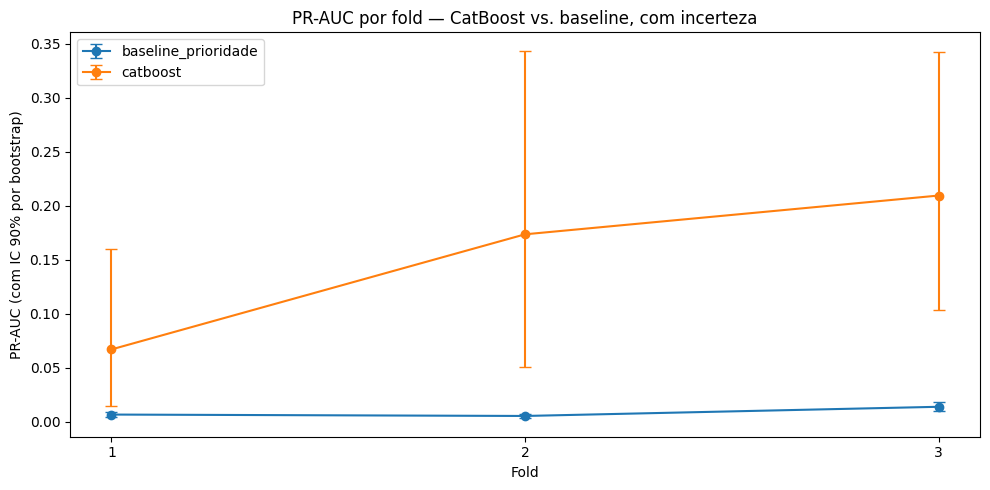

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for nome_modelo, grupo in df_comparacao.groupby('modelo'):
    ax.errorbar(
        grupo['fold'], grupo['pr_auc'],
        yerr=[grupo['pr_auc'] - grupo['pr_auc_ic_inferior'], grupo['pr_auc_ic_superior'] - grupo['pr_auc']],
        marker='o', capsize=4, label=nome_modelo,
    )
ax.set_xlabel('Fold')
ax.set_ylabel('PR-AUC (com IC 90% por bootstrap)')
ax.set_xticks([1, 2, 3])
ax.legend()
ax.set_title('PR-AUC por fold — CatBoost vs. baseline, com incerteza')
plt.tight_layout()
plt.show()


## 8. Calibração de threshold por custo de negócio

**Nota de escopo** os valores abaixo são **ilustrativos** (proporção 1:15, refletindo a intuição de que um SLA estourado custa mais caro que uma verificação extra).

**[REV 06/09] Pendência 2 — escolha e avaliação separadas.** Na versão anterior, o threshold era escolhido no `y_true`/`y_score` do **teste** do fold 3 e a precisão/recall reportadas vinham do mesmo conjunto: otimista por construção. Agora:

1. o threshold é escolhido numa **fatia de validação temporal interna do treino do fold 3** (mesma regra do Optuna, `calibrar_threshold_fold`);
2. esse threshold fixo é então **aplicado ao teste real** do fold 3 (`avaliar_threshold`) para reportar precisão/recall honestas;
3. o jeito antigo continua calculado ao lado, só para registrar a diferença — se divergir muito, isso é um achado a explicar, não a esconder.


In [ ]:
CUSTO_FALSO_POSITIVO_ILUSTRATIVO = 1
CUSTO_FALSO_NEGATIVO_ILUSTRATIVO = 15

f3 = folds[-1]
r3 = resultados_folds[3]
df_treino_f3, df_teste_f3 = aplicar_fold_por_timestamp(df_modelo, TIME_COL, f3)

# 1) threshold escolhido SÓ no treino do fold (validação interna temporal)
calibracao_validacao = calibrar_threshold_fold(
    df_treino_f3, target_col=TARGET_COL, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES,
    time_col=TIME_COL, params=r3['params'],
    custo_falso_positivo=CUSTO_FALSO_POSITIVO_ILUSTRATIVO, custo_falso_negativo=CUSTO_FALSO_NEGATIVO_ILUSTRATIVO,
    frac_validacao=0.2,
)
logger.info('Threshold escolhido na validação interna (fold 3, %d positivos em %d): %.4f',
            calibracao_validacao['n_positivos_validacao'], calibracao_validacao['n_validacao'], calibracao_validacao['threshold_otimo'])

# 2) threshold FIXO aplicado ao teste real do fold 3
avaliacao_teste_threshold = avaliar_threshold(r3['y_true'], r3['y_score_catboost'], calibracao_validacao['threshold_otimo'])
logger.info('Aplicado ao teste do fold 3: %s', avaliacao_teste_threshold)

# 3) referência: o jeito antigo (threshold escolhido no próprio teste) — só para medir o otimismo
calibracao_antiga_no_teste = calibrar_threshold_por_custo(
    r3['y_true'], r3['y_score_catboost'],
    custo_falso_positivo=CUSTO_FALSO_POSITIVO_ILUSTRATIVO, custo_falso_negativo=CUSTO_FALSO_NEGATIVO_ILUSTRATIVO,
)
logger.info('Referência (jeito antigo, escolhido no teste): threshold=%.4f | precisão=%.3f | recall=%.3f',
            calibracao_antiga_no_teste['threshold_otimo'], calibracao_antiga_no_teste['precisao_no_threshold'], calibracao_antiga_no_teste['recall_no_threshold'])

comparacao_threshold = pd.DataFrame([
    {'metodo': 'validação interna -> aplicado no teste (correto)', 'threshold': calibracao_validacao['threshold_otimo'],
     'precisao_no_teste': avaliacao_teste_threshold['precisao'], 'recall_no_teste': avaliacao_teste_threshold['recall'], 'n_alertas': avaliacao_teste_threshold['n_alertas']},
    {'metodo': 'escolhido no próprio teste (referência antiga)', 'threshold': calibracao_antiga_no_teste['threshold_otimo'],
     'precisao_no_teste': calibracao_antiga_no_teste['precisao_no_threshold'], 'recall_no_teste': calibracao_antiga_no_teste['recall_no_threshold'], 'n_alertas': None},
]).round(4)
comparacao_threshold

2026-09-10 22:32:55 | INFO     | catboost_risco | Threshold escolhido na validação interna (fold 3, 23 positivos em 4445): 0.6144


INFO:catboost_risco:Threshold escolhido na validação interna (fold 3, 23 positivos em 4445): 0.6144


2026-09-10 22:32:55 | INFO     | catboost_risco | Aplicado ao teste do fold 3: {'threshold': 0.6143681378272468, 'precisao': 0.5714, 'recall': 0.1176, 'vp': 4, 'fp': 3, 'fn': 30, 'n_alertas': 7}


INFO:catboost_risco:Aplicado ao teste do fold 3: {'threshold': 0.6143681378272468, 'precisao': 0.5714, 'recall': 0.1176, 'vp': 4, 'fp': 3, 'fn': 30, 'n_alertas': 7}


2026-09-10 22:32:55 | INFO     | catboost_risco | Referência (jeito antigo, escolhido no teste): threshold=0.4621 | precisão=0.321 | recall=0.265


INFO:catboost_risco:Referência (jeito antigo, escolhido no teste): threshold=0.4621 | precisão=0.321 | recall=0.265


,metodo,threshold,precisao_no_teste,recall_no_teste,n_alertas
0,validação interna -> aplicado no teste (correto),0.6144,0.5714,0.1176,7.0
1,escolhido no próprio teste (referência antiga),0.4621,0.3214,0.2647,NaN


## 9. Modelo de produção

Treinado com 100% do universo elegível disponível, usando os hiperparâmetros do fold mais recente (fold 3) como ponto de partida — é a configuração validada mais próxima do cenário real de implantação.

In [ ]:
modelo_producao = treinar_catboost_producao(
    df_modelo, target_col=TARGET_COL, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES,
    params=resultados_folds[3]['params'], time_col=TIME_COL,
)
logger.info('Modelo de produção treinado com %d chamados elegíveis (todo o histórico disponível).', len(df_modelo))

2026-09-10 22:37:46 | INFO     | catboost_risco | Modelo de produção treinado com 25156 chamados elegíveis (todo o histórico disponível).


INFO:catboost_risco:Modelo de produção treinado com 25156 chamados elegíveis (todo o histórico disponível).


## 10. Importância de features (nativa do CatBoost)

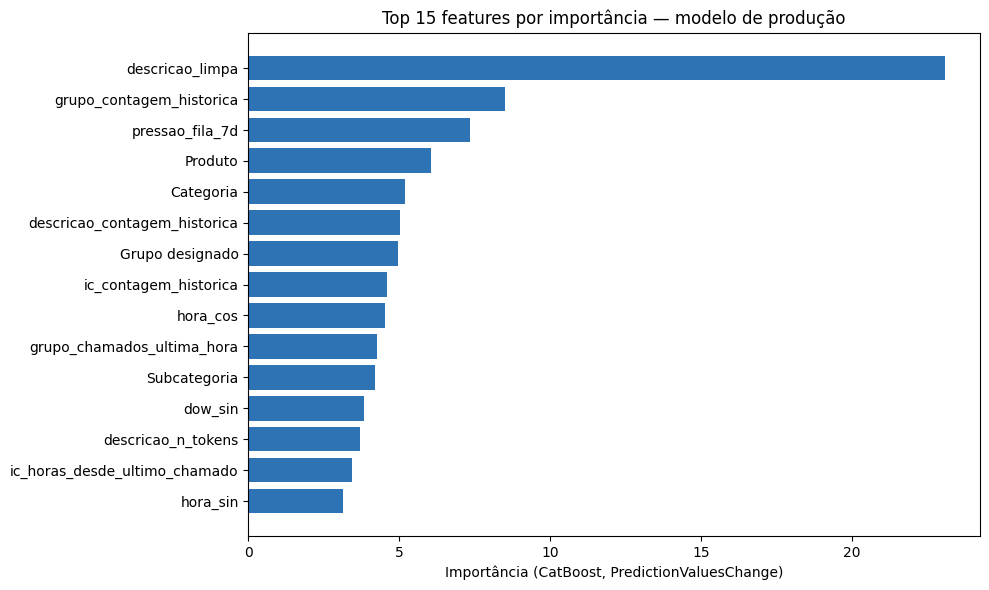

,feature,importancia
0,descricao_limpa,23.090709
1,grupo_contagem_historica,8.519986
2,pressao_fila_7d,7.356349
3,Produto,6.051644
4,Categoria,5.181186
5,descricao_contagem_historica,5.020534
6,Grupo designado,4.968766
7,ic_contagem_historica,4.598839
8,hora_cos,4.524399
9,grupo_chamados_ultima_hora,4.266347


In [ ]:
importancias = modelo_producao.get_feature_importance(prettified=True)
importancias.columns = ['feature', 'importancia']
importancias = importancias.sort_values('importancia', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importancias['feature'][::-1], importancias['importancia'][::-1], color='#2E74B5')
ax.set_xlabel('Importância (CatBoost, PredictionValuesChange)')
ax.set_title('Top 15 features por importância — modelo de produção')
plt.tight_layout()
plt.show()

importancias

## 11. Checagens de sanidade

In [ ]:
assert set(['Resolvido', 'Encerrado', 'Duração', 'Status']).isdisjoint(df_modelo.columns), 'Coluna de vazamento entrou no modelo!'
assert df_elegivel['grupo_baixo_volume'].mean() > 0, 'Correção do bug de grupo_baixo_volume não se sustentou!'
assert len(resultados_folds) == 3
for fold_num, r in resultados_folds.items():
    assert r['avaliacao_catboost']['n_positivos'] > 0, f'Fold {fold_num} sem nenhum positivo no teste!'
logger.info('Checagens de sanidade: OK.')

2026-09-10 22:37:47 | INFO     | catboost_risco | Checagens de sanidade: OK.


INFO:catboost_risco:Checagens de sanidade: OK.


## 12. Resumo de execução

In [ ]:
resumo_execucao = f'''
EXECUÇÃO DO MODELO CATBOOST (Desafio 3) — {pd.Timestamp.now(tz="UTC").isoformat()}
Universo elegível: {len(df_elegivel):,} chamados | Positivos: {df_elegivel["target"].sum()} ({df_elegivel["target"].mean()*100:.2f}%)

Comparação CatBoost vs. baseline (PR-AUC, média ± desvio-padrão entre folds):
{resumo_comparacao.to_string()}

Calibração de threshold (fold 3, custo ilustrativo 1:15) — [REV 06/09] escolhido na validação interna, aplicado ao teste:
{comparacao_threshold.to_string(index=False)}

Modelo de produção: treinado com {len(df_modelo):,} chamados elegíveis, hiperparâmetros do fold 3.
Top 3 features por importância: {importancias["feature"].head(3).tolist()}
'''.strip()

print(resumo_execucao)

EXECUÇÃO DO MODELO CATBOOST (Desafio 3) — 2026-09-10T22:37:47.072890+00:00
Universo elegível: 25,156 chamados | Positivos: 238 (0.95%)

Comparação CatBoost vs. baseline (PR-AUC, média ± desvio-padrão entre folds):
                     pr_auc         roc_auc_referencia         precision_at_10         precision_at_20        
                       mean     std               mean     std            mean     std            mean     std
modelo                                                                                                        
baseline_prioridade  0.0088  0.0046             0.5206  0.0176          0.0000  0.0000          0.0000  0.0000
catboost             0.1501  0.0741             0.8075  0.0186          0.3333  0.2082          0.2333  0.1756

Calibração de threshold (fold 3, custo ilustrativo 1:15) — [REV 06/09] escolhido na validação interna, aplicado ao teste:
                                          metodo  threshold  precisao_no_teste  recall_no_teste  n_alertas
v

In [ ]:
caminho_modelo = salvar_modelo_catboost(modelo_producao, PROJECT_PATHS.gold / 'modelos' / 'catboost_producao.cbm')
logger.info('Modelo CatBoost salvo em: %s', caminho_modelo)

2026-09-10 22:37:47 | INFO     | catboost_risco | Modelo CatBoost salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/catboost_producao.cbm


INFO:catboost_risco:Modelo CatBoost salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/catboost_producao.cbm
